# 01 - REINFORCE su CartPole

Questo notebook imposta una prima baseline di Deep Reinforcement Learning su CartPole usando `REINFORCE`.

## Setup

Importiamo le librerie essenziali, agganciamo la cartella principale della repository e carichiamo le funzioni riutilizzabili definite in `DLA_LAB3/src`.

In [1]:
from pathlib import Path
import sys

import gymnasium as gym
import pandas as pd
import torch
import yaml
from torch.optim import Adam

current_dir = Path.cwd().resolve()
for candidate in [current_dir, *current_dir.parents]:
    if (candidate / "DLA_LAB3" / "src").exists():
        project_root = candidate
        break
else:
    raise RuntimeError("Eseguire il notebook dalla repository Deep_Learning_Laboratories.")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from DLA_LAB3.src.evaluation import evaluate_policy, render_policy
from DLA_LAB3.src.networks import PolicyNetwork
from DLA_LAB3.src.plotting import plot_seed_eval_curves
from DLA_LAB3.src.reinforce import compute_discounted_returns, train_reinforce
from DLA_LAB3.src.utils import get_device, restore_model_state, seed_environment, set_seed

In [2]:
config_path = project_root / "DLA_LAB3" / "exercise_1_reinforce_cartpole" / "config.yaml"
raw_config = yaml.safe_load(config_path.read_text())

CONFIG = {
    "environment_name": raw_config["environment"]["name"],
    "max_steps": raw_config["environment"]["max_steps"],
    "seeds": raw_config["training"]["seeds"],
    "num_episodes": raw_config["training"]["num_episodes"],
    "gamma": raw_config["training"]["gamma"],
    "learning_rate": raw_config["training"]["learning_rate"],
    "hidden_dim": raw_config["training"]["hidden_dim"],
    "standardize_returns": raw_config["training"]["standardize_returns"],
    "force_cpu": raw_config["training"]["force_cpu"],
    "evaluation_episodes": raw_config["evaluation"]["num_episodes"],
    "deterministic_eval": raw_config["evaluation"]["deterministic"],
    "eval_every_n": raw_config["evaluation"]["eval_every_n"],
    "eval_episodes_m": raw_config["evaluation"]["eval_episodes_m"],
}

set_seed(CONFIG["seeds"][0])
device = get_device(force_cpu=CONFIG["force_cpu"])
device

device(type='cpu')

## Ambiente CartPole

Prima di addestrare l'agente controllo la struttura dell'ambiente. CartPole restituisce uno stato numerico continuo e richiede una scelta tra due azioni discrete: spinta a sinistra o spinta a destra.

Il reward e' molto diretto: l'agente viene premiato finche' il palo resta in equilibrio. Quindi, in questo caso, un episodio piu' lungo corrisponde anche a un reward totale piu' alto.

In [3]:
env = gym.make(CONFIG["environment_name"])
observation, info = seed_environment(env, CONFIG["seeds"][0])

print("Observation iniziale:", observation)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Info reset:", info)

Observation iniziale: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Info reset: {}


### Osservazioni

- Il device usa la CPU, come indicato nel file `config.yaml`.
- Lo stato di CartPole ha 4 variabili continue.
- Lo spazio delle azioni ha 2 scelte: spinta a sinistra o spinta a destra.

## Ritorno scontato

Per aggiornare la policy non considero solo il reward immediato, ma il ritorno futuro scontato:

$$G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + ...$$

Il parametro `gamma` serve a dare piu' peso ai reward vicini e meno peso a quelli lontani. In pratica rende il segnale di training meno rumoroso rispetto alla somma grezza di tutti i reward futuri.

In [4]:
example_rewards = [1.0, 1.0, 1.0, 1.0]
compute_discounted_returns(example_rewards, gamma=CONFIG["gamma"])

tensor([3.9404, 2.9701, 1.9900, 1.0000])

### Osservazioni

- Con quattro reward unitari e `gamma=0.99`, il primo ritorno vale circa 3.94 invece di 4.
- La differenza e' piccola per episodi brevi, ma diventa importante quando gli episodi sono lunghi e i reward futuri sono piu' incerti.

## Policy network

La policy network prende in input lo stato di CartPole e produce un punteggio per ciascuna azione. Per ogni seed viene inizializzata una nuova policy, cosi' le run restano indipendenti.

In [5]:
observation_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("Observation dim:", observation_dim)
print("Action dim:", action_dim)

Observation dim: 4
Action dim: 2


## Training con REINFORCE

Eseguo lo stesso esperimento su 5 seed. Ogni seed usa una nuova policy, un nuovo ottimizzatore e un nuovo ambiente.

Ogni 20 episodi la policy viene valutata in modo deterministico per 10 episodi. La valutazione finale usa il miglior checkpoint osservato durante queste valutazioni periodiche.

In [6]:
training_results = {}
trained_policies = {}
summary_rows = []

for seed in CONFIG["seeds"]:
    print(f"Run seed {seed}")
    set_seed(seed)

    train_env = gym.make(CONFIG["environment_name"])
    seed_environment(train_env, seed)

    policy = PolicyNetwork(
        observation_dim=observation_dim,
        action_dim=action_dim,
        hidden_dim=CONFIG["hidden_dim"],
    ).to(device)
    optimizer = Adam(policy.parameters(), lr=CONFIG["learning_rate"])

    eval_env_inter = gym.make(CONFIG["environment_name"])
    seed_environment(eval_env_inter, seed)

    training_result = train_reinforce(
        env=train_env,
        policy=policy,
        optimizer=optimizer,
        device=device,
        num_episodes=CONFIG["num_episodes"],
        gamma=CONFIG["gamma"],
        max_steps=CONFIG["max_steps"],
        standardize_returns=CONFIG["standardize_returns"],
        eval_env=eval_env_inter,
        eval_every_n=CONFIG["eval_every_n"],
        eval_episodes_m=CONFIG["eval_episodes_m"],
    )
    train_env.close()
    eval_env_inter.close()

    restore_model_state(policy, training_result.best_policy_state)

    eval_env = gym.make(CONFIG["environment_name"])
    seed_environment(eval_env, seed)
    evaluation = evaluate_policy(
        env=eval_env,
        policy=policy,
        device=device,
        num_episodes=CONFIG["evaluation_episodes"],
        max_steps=CONFIG["max_steps"],
        deterministic=CONFIG["deterministic_eval"],
    )
    eval_env.close()

    training_results[seed] = training_result
    trained_policies[seed] = policy

    row = {
        "Seed": seed,
        "Final Train Reward": round(training_result.episode_rewards[-1], 1),
        "Best Train Reward": round(max(training_result.episode_rewards), 1),
        "Eval Mean Reward": round(evaluation["mean_reward"], 1),
        "Eval Min Reward": round(evaluation["min_reward"], 1),
        "Eval Max Reward": round(evaluation["max_reward"], 1),
        "Eval Mean Length": round(evaluation["mean_length"], 1),
        "Best Checkpoint Episode": training_result.best_eval_episode,
        "Best Checkpoint Reward": round(training_result.best_eval_mean_reward, 1),
    }
    summary_rows.append(row)
    print(row)

results_table = pd.DataFrame(summary_rows)
best_seed = int(results_table.sort_values("Eval Mean Reward", ascending=False).iloc[0]["Seed"])
best_policy = trained_policies[best_seed]

display(results_table)
print("Seed migliore in valutazione:", best_seed)

Run seed 42
{'Seed': 42, 'Final Train Reward': 144.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 500.0, 'Eval Min Reward': 500.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 500.0, 'Best Checkpoint Episode': 300, 'Best Checkpoint Reward': 500.0}
Run seed 123
{'Seed': 123, 'Final Train Reward': 500.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 500.0, 'Eval Min Reward': 500.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 500.0, 'Best Checkpoint Episode': 220, 'Best Checkpoint Reward': 500.0}
Run seed 314
{'Seed': 314, 'Final Train Reward': 444.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 500.0, 'Eval Min Reward': 500.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 500.0, 'Best Checkpoint Episode': 200, 'Best Checkpoint Reward': 492.5}
Run seed 2024
{'Seed': 2024, 'Final Train Reward': 43.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 493.0, 'Eval Min Reward': 430.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 493.0, 'Best Checkpoint Episode': 260, 'Best Checkpoi

,Seed,Final Train Reward,Best Train Reward,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length,Best Checkpoint Episode,Best Checkpoint Reward
0,42,144.0,500.0,500.0,500.0,500.0,500.0,300,500.0
1,123,500.0,500.0,500.0,500.0,500.0,500.0,220,500.0
2,314,444.0,500.0,500.0,500.0,500.0,500.0,200,492.5
3,2024,43.0,500.0,493.0,430.0,500.0,493.0,260,500.0
4,9001,226.0,500.0,500.0,500.0,500.0,500.0,140,500.0


Seed migliore in valutazione: 42


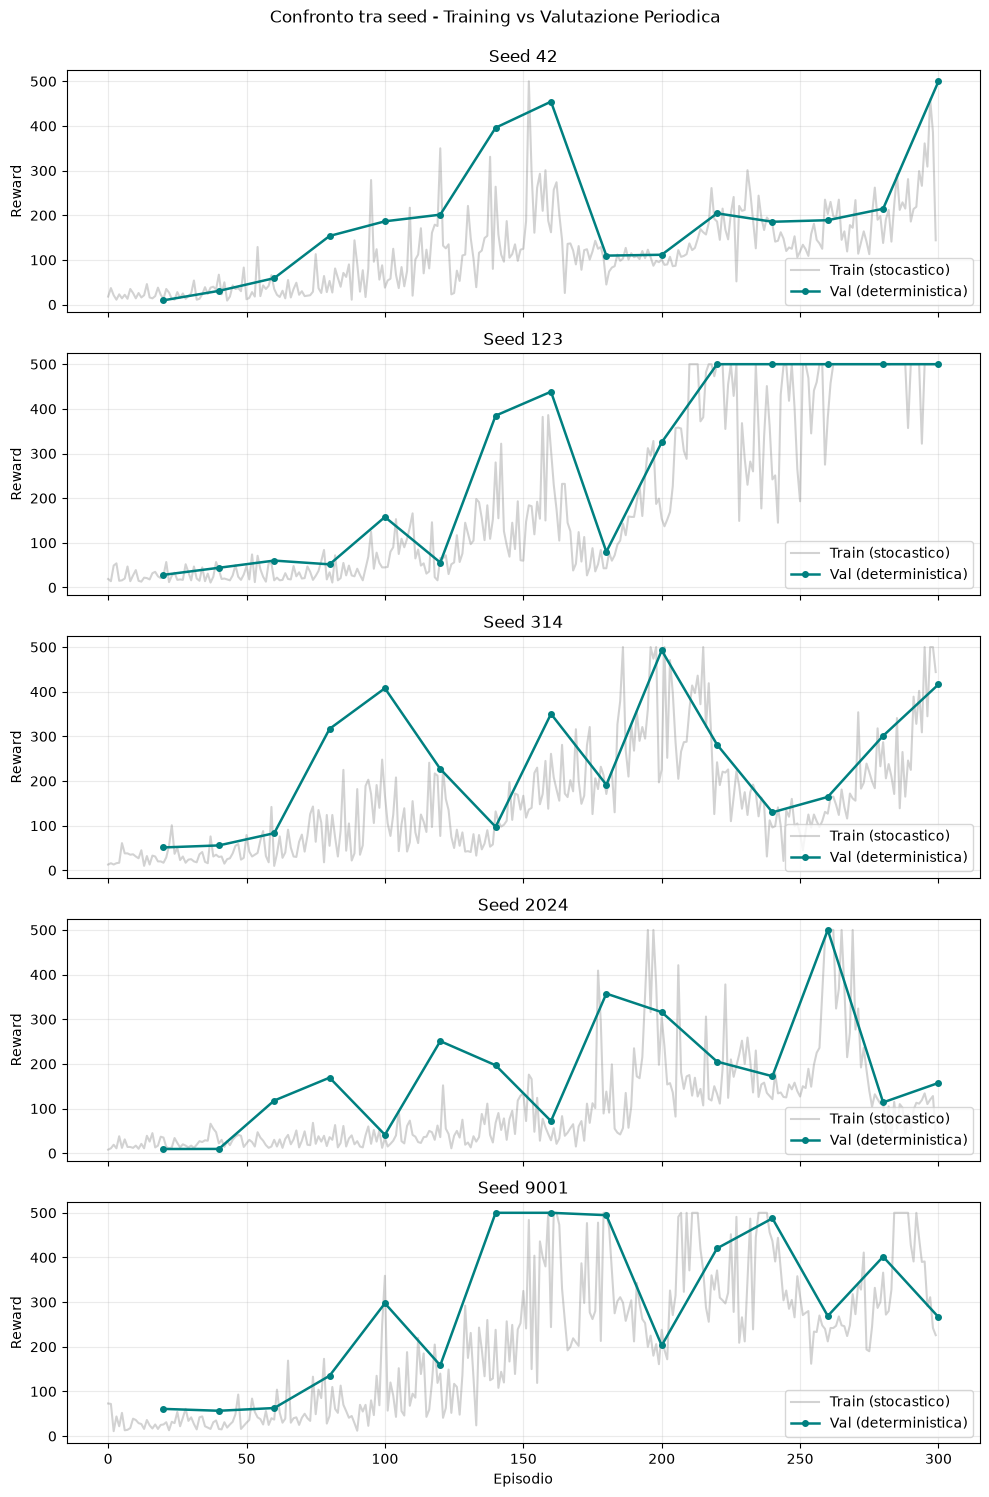

In [7]:
plot_seed_eval_curves(
    {
        seed: {
            "train_rewards": result.episode_rewards,
            "eval_intervals": result.eval_episodes,
            "eval_rewards": result.eval_mean_rewards,
        }
        for seed, result in training_results.items()
    }
)

### Osservazioni

- Il grafico mostra la valutazione deterministica ogni 20 episodi.
- Ogni punto usa la media di 10 episodi di valutazione.
- Il reward grezzo di training resta visibile in grigio, ma non è la metrica principale.
- Seed 2024 è il caso peggiore nella valutazione finale.

## Valutazione finale

La tabella finale riporta reward medio e lunghezza media su 10 episodi deterministici usando il miglior checkpoint salvato in memoria per ogni seed.

In CartPole il reward cresce di 1 per ogni step, quindi reward medio e lunghezza media hanno lo stesso valore numerico.

In [8]:
results_table.sort_values("Eval Mean Reward", ascending=False).reset_index(drop=True)

,Seed,Final Train Reward,Best Train Reward,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length,Best Checkpoint Episode,Best Checkpoint Reward
0,42,144.0,500.0,500.0,500.0,500.0,500.0,300,500.0
1,123,500.0,500.0,500.0,500.0,500.0,500.0,220,500.0
2,314,444.0,500.0,500.0,500.0,500.0,500.0,200,492.5
3,9001,226.0,500.0,500.0,500.0,500.0,500.0,140,500.0
4,2024,43.0,500.0,493.0,430.0,500.0,493.0,260,500.0


### Osservazioni

- Seed 42, 123, 314 e 9001: reward medio e lunghezza media pari a 500.0.
- Seed 2024: reward medio 493.0, lunghezza media 493.0, unico caso sotto il massimo.
- Uso uno dei seed con valutazione massima per la visualizzazione finale.

## Visualizzazione real time

Visualizzo una policy con reward medio di valutazione massimo. La finestra mostra direttamente il carrello e il palo controllati dalla policy finale.

In [9]:
render_rewards = render_policy(
    environment_name=CONFIG["environment_name"],
    policy=best_policy,
    device=device,
    num_episodes=3,
    max_steps=CONFIG["max_steps"],
    deterministic=True,
    frame_delay=0.02,
)

print("Reward episodi renderizzati:", render_rewards)

Reward episodi renderizzati: [500.0, 500.0, 500.0]


### Osservazioni

- Il rendering usa la policy selezionata dalla valutazione.
- La visualizzazione non modifica i pesi del modello.

## Osservazioni finali

- REINFORCE standard puo' risolvere CartPole, ma alcune run restano sensibili al seed.
- La metrica principale e' la valutazione periodica deterministica.
- La valutazione finale usa il miglior checkpoint osservato durante il training.
- Per ogni valutazione considero reward medio e lunghezza media degli episodi.

In [10]:
env.close()